## Check DCM image

In [1]:
import pydicom
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [26]:
def dcm_to_png_matplotlib(dcm_path, png_path, is_only_show=False):
    """
    pydicomとmatplotlibを使ってDICOM画像をPNGに変換します。

    Args:
        dcm_path (str): DICOMファイルのパス。
        png_path (str): 保存するPNGファイルのパス。
    """
    try:
        # DICOMファイルの読み込み
        dcm = pydicom.dcmread(dcm_path)

        # ピクセルデータの取得と正規化
        pixel_array = dcm.pixel_array
        if pixel_array.dtype != np.uint8:
            pixel_array = (pixel_array - pixel_array.min()) / (pixel_array.max() - pixel_array.min()) * 255
            pixel_array = pixel_array.astype(np.uint8)

        # matplotlibで表示して保存
        plt.imshow(pixel_array, cmap=plt.cm.gray)
        plt.axis('off')  # 軸を非表示にする
        plt.savefig(png_path, bbox_inches='tight', pad_inches=0)
        plt.close()
        print(f"'Converted {dcm_path}' to '{png_path}'")

    except Exception as e:
        print(f"Raised error: {e}")


In [3]:
import os

In [28]:
dcm_path = '/Users/xxx/hobby/datasets/siim-acr-pneumothorax-segmentation/stage_2_images/ID_ed3c71fcc.dcm'
png_path = '/Users/xxx/hobby/datasets/siim-acr-pneumothorax-segmentation/train_png/ID_ed3c71fcc.png'

In [10]:
os.path.exists(dcm_path) 

True

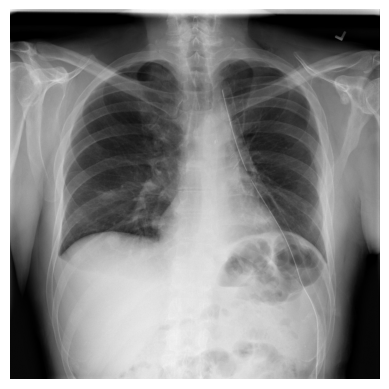

In [16]:
dcm_to_png_matplotlib(dcm_path, png_path, True)

In [17]:
dcm_to_png_matplotlib(dcm_path, png_path)

'Converted /Users/atsushi-takahiro@cookpad.com/hobby/datasets/siim-acr-pneumothorax-segmentation/stage_2_images/ID_ed3c71fcc.dcm' to '/Users/atsushi-takahiro@cookpad.com/hobby/datasets/siim-acr-pneumothorax-segmentation/train_png/ID_ed3c71fcc.png'


<Figure size 640x480 with 0 Axes>

In [29]:
dcm_directory = '/Users/xxx/hobby/datasets/siim-acr-pneumothorax-segmentation/stage_2_images/'
png_directory = '/Users/xxx/hobby/datasets/siim-acr-pneumothorax-segmentation/train_png/'

# for filename in os.listdir(dcm_directory):
#     if filename.endswith('.dcm'):
#         dcm_filepath = os.path.join(dcm_directory, filename)
#         png_filename = filename.replace('.dcm', '.png')
#         png_filepath = os.path.join(png_directory, png_filename)
#         dcm_to_png_matplotlib(dcm_filepath, png_filepath)

print("すべての DICOM ファイルの PNG 変換が完了しました。")

すべての DICOM ファイルの PNG 変換が完了しました。
